# Feature Engineering Climático (Mensal) – Vale do São Francisco

**Objetivo:** gerar variáveis climáticas mensalmente agregadas para suportar modelos de predição de produtividade (ex.: uva e manga).

**Escopo deste notebook:**
- Carregar dados climáticos (mensal) e produção (anual)
- Criar features climáticas interpretáveis (GDD, déficit hídrico, stress, amplitude térmica, etc.)
- Expandir produção para mensal e fazer merge
- Exportar dataset final pronto para modelagem


In [ ]:
import pandas as pd
import numpy as np
import os # Importar o módulo os para criar diretórios

import matplotlib.pyplot as plt
from scipy.stats import norm

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

# Caminhos (ajuste se necessário)
PATH_CLIMA = "/content/clima_mensal_consolidado.csv" # Caminho corrigido
PATH_PRODUCAO = "/content/pam_censo_agro_integrado_v2.csv"
OUTPUT_DATASET = "data/processed/dataset_ml_completo.csv"
OUTPUT_CORR_PNG = "data/processed/feature_importance_correlacao.png"

# Criar diretório de saída se não existir
os.makedirs(os.path.dirname(OUTPUT_DATASET), exist_ok=True)


## Contrato de dados (schema)

Para manter o notebook **reprodutível e robusto**, validamos as colunas mínimas necessárias.
Colunas adicionais podem existir e serão preservadas.


In [ ]:
REQUIRED_CLIMA = {
    "ano",
    "mes",
    "municipio",
    "temp_media_mensal",
    "temp_maxima_mensal",
    "temp_minima_mensal",
    "precipitacao_acumulada_mm",
    "eto_acumulada_mm",
}

REQUIRED_PRODUCAO = {
    "ano",
    "municipio",
    "produto",
    "quantidade_produzida_t",  # target
    "preco_medio_r$_kg",
    "area_colhida_ha",
    "rendimento_medio_kg_ha",
}

def validate_schema(df: pd.DataFrame, required: set, df_name: str) -> None:
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"[{df_name}] Colunas ausentes: {sorted(missing)}")

def standardize_municipio(series: pd.Series) -> pd.Series:
    """Padroniza nomes de municípios removendo sufixos como '(BA)', '(PE)' e espaços extras."""
    return (
        series.astype(str)
        .str.replace(r"\s*\(.*\)\s*", "", regex=True)
        .str.strip()
        .str.upper()
    )

# Carregar dados
df_clima = pd.read_csv(PATH_CLIMA)
df_producao = pd.read_csv(PATH_PRODUCAO)

validate_schema(df_clima, REQUIRED_CLIMA, "df_clima")
validate_schema(df_producao, REQUIRED_PRODUCAO, "df_producao")

# Padronizar chaves
df_clima["municipio"] = standardize_municipio(df_clima["municipio"])
df_producao["municipio"] = standardize_municipio(df_producao["municipio"])

# Garantir tipos básicos
df_clima["ano"] = df_clima["ano"].astype(int)
df_clima["mes"] = df_clima["mes"].astype(int)
df_producao["ano"] = df_producao["ano"].astype(int)

print("✅ Dados carregados e schema validado")
print("df_clima:", df_clima.shape, "| df_producao:", df_producao.shape)


✅ Dados carregados e schema validado
df_clima: (288, 9) | df_producao: (48, 10)


## Funções de feature engineering

Features climáticas (mensais) com interpretação agronômica.


In [ ]:
def calcular_gdd(temp_media: pd.Series, temp_base: float = 10.0) -> pd.Series:
    """GDD (Growing Degree Days): max(temp_media - temp_base, 0)."""
    return np.maximum(temp_media - temp_base, 0)

def calcular_deficit_hidrico(precipitacao_mm: pd.Series, eto_mm: pd.Series) -> pd.Series:
    """Déficit hídrico simples (mm): precipitação - ETo."""
    return precipitacao_mm - eto_mm

def calcular_indice_stress(precipitacao_mm: pd.Series, eto_mm: pd.Series) -> pd.Series:
    """Índice de stress hídrico (0–100). Quanto maior, maior o stress por falta de água."""
    stress = np.where(eto_mm > 0, (1 - (precipitacao_mm / eto_mm)) * 100, 0.0)
    return np.clip(stress, 0, 100)

def calcular_amplitude_termica(tmax: pd.Series, tmin: pd.Series) -> pd.Series:
    """Amplitude térmica mensal: Tmax - Tmin."""
    return tmax - tmin

def estimar_dias_temp_otima(
    temp_media: float,
    temp_min: float,
    temp_max: float,
    dias_mes: int = 30,
    temp_ideal_min: float = 20.0,
    temp_ideal_max: float = 30.0,
) -> float:
    """
    Estima quantos dias no mês tiveram temperatura entre [temp_ideal_min, temp_ideal_max].
    Supõe distribuição normal intra-mês e aproxima desvio padrão via regra empírica:
      std \u2248 (temp_max - temp_min) / 4
    """
    std = (temp_max - temp_min) / 4.0

    if std == 0 or np.isnan(std):
        return float(dias_mes) if temp_ideal_min <= temp_media <= temp_ideal_max else 0.0

    prob_ideal = (
        norm.cdf(temp_ideal_max, loc=temp_media, scale=std)
        - norm.cdf(temp_ideal_min, loc=temp_media, scale=std)
    )
    return float(prob_ideal * dias_mes)

def build_climate_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["gdd_mensal"] = calcular_gdd(df["temp_media_mensal"])
    df["deficit_hidrico_mm"] = calcular_deficit_hidrico(
        df["precipitacao_acumulada_mm"], df["eto_acumulada_mm"]
    )
    df["indice_stress_hidrico"] = calcular_indice_stress(
        df["precipitacao_acumulada_mm"], df["eto_acumulada_mm"]
    )
    df["amplitude_termica"] = calcular_amplitude_termica(
        df["temp_maxima_mensal"], df["temp_minima_mensal"]
    )

    df["dias_temp_otima_est"] = df.apply(
        lambda r: estimar_dias_temp_otima(
            r["temp_media_mensal"], r["temp_minima_mensal"], r["temp_maxima_mensal"]
        ),
        axis=1,
    )

    return df

df_clima_feat = build_climate_features(df_clima)

print("\u2705 Features climáticas criadas")
display(df_clima_feat.head())


✅ Features climáticas criadas


,municipio,ano,mes,temp_media_mensal,temp_maxima_mensal,temp_minima_mensal,precipitacao_acumulada_mm,eto_acumulada_mm,vento_medio_mensal,gdd_mensal,deficit_hidrico_mm,indice_stress_hidrico,amplitude_termica,dias_temp_otima_est
0,JUAZEIRO,2013,1,28.264516,36.1,22.5,65.0,191.02,18.980645,18.264516,-126.02,65.972150,13.6,20.627794
1,JUAZEIRO,2013,2,29.596429,36.8,22.3,0.1,230.28,23.467857,19.596429,-230.18,99.956575,14.5,16.207971
2,JUAZEIRO,2013,3,29.554839,38.4,22.3,18.2,218.93,20.067742,19.554839,-200.73,91.686841,16.1,16.056947
3,JUAZEIRO,2013,4,27.566667,36.4,21.3,32.4,162.28,22.010000,17.566667,-129.88,80.034508,15.1,21.536738
4,JUAZEIRO,2013,5,26.645161,35.1,21.1,6.3,164.10,22.487097,16.645161,-157.80,96.160878,14.0,24.068809


## Preparar produção para granularidade mensal

Os dados de produção são anuais; para cruzar com clima mensal, replicamos os registros para os 12 meses.


In [ ]:
# Expansão anual -> mensal (vetorizado)
df_meses = pd.DataFrame({"mes": np.arange(1, 13, dtype=int)})
df_producao_mensal = (
    df_producao.assign(_tmp=1)
    .merge(df_meses.assign(_tmp=1), on="_tmp", how="inner")
    .drop(columns=["_tmp"])
)

print("✅ Produção expandida para mensal:", df_producao_mensal.shape)
display(df_producao_mensal.head())


✅ Produção expandida para mensal: (576, 11)


,municipio,ano,produto,area_colhida_ha,quantidade_produzida_t,rendimento_medio_kg_ha,preco_mediano_r$_kg,preco_medio_r$_kg,preco_std_r$_kg,num_observacoes_preco,mes
0,JUAZEIRO,2013,Manga,8086,210236,26000,1.365,1.365,0.417193,2,1
1,JUAZEIRO,2013,Manga,8086,210236,26000,1.365,1.365,0.417193,2,2
2,JUAZEIRO,2013,Manga,8086,210236,26000,1.365,1.365,0.417193,2,3
3,JUAZEIRO,2013,Manga,8086,210236,26000,1.365,1.365,0.417193,2,4
4,JUAZEIRO,2013,Manga,8086,210236,26000,1.365,1.365,0.417193,2,5


## Merge clima + produção

Chaves: `ano`, `mes`, `municipio`. Mantemos apenas interseção (inner) para dataset final consistente.


In [ ]:
df_ml = pd.merge(
    df_producao_mensal,
    df_clima_feat,
    on=["ano", "mes", "municipio"],
    how="inner",
)

print("✅ Merge concluído")
print("df_ml:", df_ml.shape)
print("Período:", df_ml["ano"].min(), "-", df_ml["ano"].max())
print("Municípios:", df_ml["municipio"].nunique())
print("Produtos:", df_ml["produto"].nunique())

missing = df_ml.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing):
    print("\n⚠️ Missing values (top):")
    display(missing.head(20))
else:
    print("\n✅ Sem missing values no dataset merged (na checagem básica)")


✅ Merge concluído
df_ml: (576, 22)
Período: 2013 - 2024
Municípios: 2
Produtos: 2

✅ Sem missing values no dataset merged (na checagem básica)


## Seleção de colunas e export

Selecionamos IDs, target, variáveis de produção e features climáticas.  
O conjunto final é salvo em CSV para consumo por modelos.


In [ ]:
# Colunas base (produção)
base_cols = [
    "ano", "mes", "municipio", "produto",
    "quantidade_produzida_t",
    "preco_medio_r$_kg",
    "area_colhida_ha",
    "rendimento_medio_kg_ha",
]

# Colunas clima (inclui opcionais, se existirem)
clima_candidate_cols = [
    "temp_media_mensal",
    "temp_maxima_mensal",
    "temp_minima_mensal",
    "precipitacao_acumulada_mm",
    "eto_acumulada_mm",
    "vento_medio_mensal",          # opcional
    "gdd_mensal",
    "deficit_hidrico_mm",
    "indice_stress_hidrico",
    "amplitude_termica",
    "dias_temp_otima_est",
]

clima_cols = [c for c in clima_candidate_cols if c in df_ml.columns]
colunas_finais = base_cols + clima_cols

df_ml_final = df_ml[colunas_finais].copy()

# Salvar
df_ml_final.to_csv(OUTPUT_DATASET, index=False)

print("✅ Dataset final salvo em:", OUTPUT_DATASET)
print("Dimensões:", df_ml_final.shape)
print("Nº colunas:", len(df_ml_final.columns))
display(df_ml_final.head())


✅ Dataset final salvo em: data/processed/dataset_ml_completo.csv
Dimensões: (576, 19)
Nº colunas: 19


,ano,mes,municipio,produto,quantidade_produzida_t,preco_medio_r$_kg,area_colhida_ha,rendimento_medio_kg_ha,temp_media_mensal,temp_maxima_mensal,temp_minima_mensal,precipitacao_acumulada_mm,eto_acumulada_mm,vento_medio_mensal,gdd_mensal,deficit_hidrico_mm,indice_stress_hidrico,amplitude_termica,dias_temp_otima_est
0,2013,1,JUAZEIRO,Manga,210236,1.365,8086,26000,28.264516,36.1,22.5,65.0,191.02,18.980645,18.264516,-126.02,65.972150,13.6,20.627794
1,2013,2,JUAZEIRO,Manga,210236,1.365,8086,26000,29.596429,36.8,22.3,0.1,230.28,23.467857,19.596429,-230.18,99.956575,14.5,16.207971
2,2013,3,JUAZEIRO,Manga,210236,1.365,8086,26000,29.554839,38.4,22.3,18.2,218.93,20.067742,19.554839,-200.73,91.686841,16.1,16.056947
3,2013,4,JUAZEIRO,Manga,210236,1.365,8086,26000,27.566667,36.4,21.3,32.4,162.28,22.010000,17.566667,-129.88,80.034508,15.1,21.536738
4,2013,5,JUAZEIRO,Manga,210236,1.365,8086,26000,26.645161,35.1,21.1,6.3,164.10,22.487097,16.645161,-157.80,96.160878,14.0,24.068809


## Sanity checks e correlação com o target (rápido)

Objetivo: checar estatísticas básicas e entender direção/força de correlação (Pearson) com o target.


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ano,576.0,NaN,NaN,NaN,2018.5,3.455053,2013.0,2015.75,2018.5,2021.25,2024.0
mes,576.0,NaN,NaN,NaN,6.5,3.455053,1.0,3.75,6.5,9.25,12.0
municipio,576,2,JUAZEIRO,288,NaN,NaN,NaN,NaN,NaN,NaN,NaN
produto,576,2,Manga,288,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quantidade_produzida_t,576.0,NaN,NaN,NaN,207644.3125,139872.747105,27940.0,54212.5,178776.5,325092.0,610739.0
preco_medio_r$_kg,576.0,NaN,NaN,NaN,3.946913,2.624127,1.11,1.56125,3.671786,5.485327,10.877143
area_colhida_ha,576.0,NaN,NaN,NaN,6080.979167,3601.579465,1078.0,2093.25,6295.0,8506.75,13737.0
rendimento_medio_kg_ha,576.0,NaN,NaN,NaN,33693.25,11065.817779,17400.0,25000.0,30181.5,40862.5,58000.0
temp_media_mensal,576.0,NaN,NaN,NaN,26.809324,1.71563,22.66129,25.533871,26.874839,27.975,30.343333
temp_maxima_mensal,576.0,NaN,NaN,NaN,34.965972,1.862478,30.6,33.6,35.2,36.225,39.0


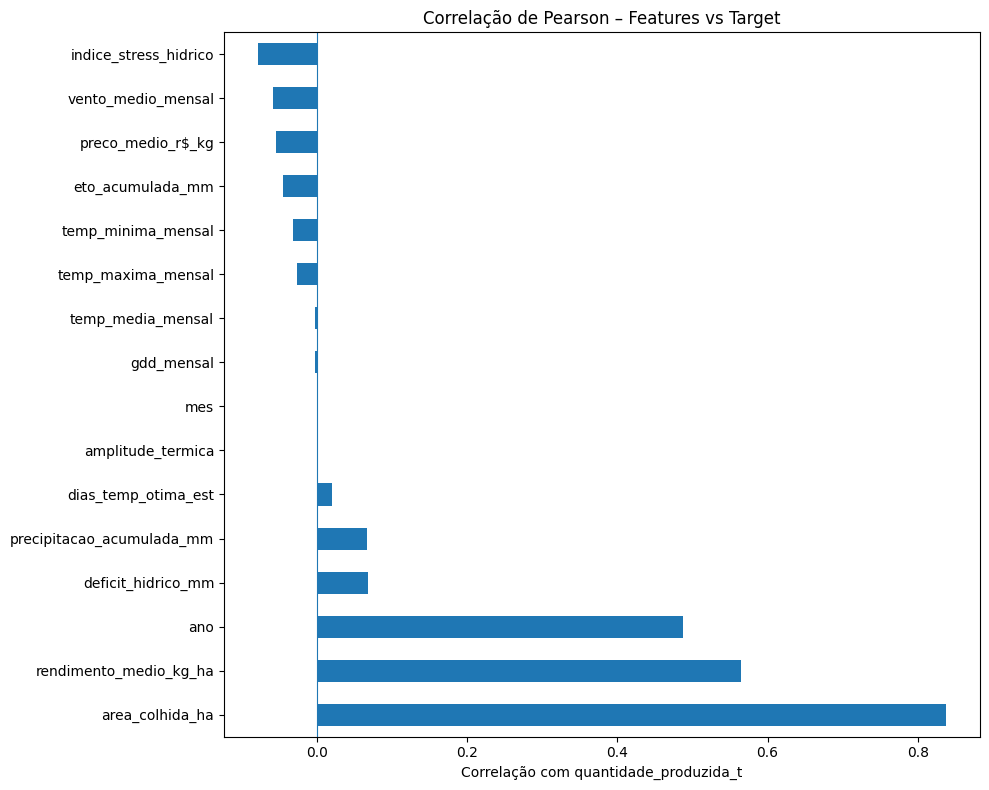

✅ Top 10 correlações (absolutas):


,quantidade_produzida_t
area_colhida_ha,0.837278
rendimento_medio_kg_ha,0.564105
ano,0.486730
indice_stress_hidrico,-0.078523
deficit_hidrico_mm,0.068091
precipitacao_acumulada_mm,0.066021
vento_medio_mensal,-0.059285
preco_medio_r$_kg,-0.054665
eto_acumulada_mm,-0.045044
temp_minima_mensal,-0.032425


In [ ]:
# Estatísticas descritivas
display(df_ml_final.describe(include="all").transpose().head(30))

# Correlação (numéricas) com target
target = "quantidade_produzida_t"
num_cols = df_ml_final.select_dtypes(include=[np.number]).columns

if target in num_cols:
    corr = df_ml_final[num_cols].corr()[target].sort_values(ascending=False)
    corr_no_target = corr.drop(target, errors="ignore")

    plt.figure(figsize=(10, 8))
    corr_no_target.plot(kind="barh")
    plt.xlabel(f"Correlação com {target}")
    plt.title("Correlação de Pearson – Features vs Target")
    plt.axvline(x=0, linewidth=0.8)
    plt.tight_layout()
    plt.savefig(OUTPUT_CORR_PNG, dpi=300, bbox_inches="tight")
    plt.show()

    print("✅ Top 10 correlações (absolutas):")
    display(corr_no_target.reindex(corr_no_target.abs().sort_values(ascending=False).index).head(10))
else:
    print(f"⚠️ Target '{target}' não está entre as colunas numéricas; verifique tipos/dados.")
